In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scikit_posthocs as sp
from utils import *

In [2]:
results = pd.concat([pd.read_csv(f).assign(file=f) for f in glob.glob("results/*.csv")]).assign(
    configuration=lambda df: df["file"].apply(lambda row: row[-9:-8]),
    scenario=lambda df: df["file"].apply(lambda row: row[-7:-6]),
    noise_level=lambda df: df["file"].apply(lambda row: row[-5:-4])
).drop("column", axis=1)

In [3]:
results

,Best model-mean_distance,Best model-root_mean_square_distance,Best model-inner-q0.05-mean_distance,Best model-inner-q0.05-root_mean_square_distance,Best model-outer-q0.05-mean_distance,Best model-outer-q0.05-root_mean_square_distance,Best model-inner-q0.1-mean_distance,Best model-inner-q0.1-root_mean_square_distance,Best model-outer-q0.1-mean_distance,Best model-outer-q0.1-root_mean_square_distance,...,Best stacked ensemble-inner-q0.1-root_mean_square_distance,Best stacked ensemble-outer-q0.1-mean_distance,Best stacked ensemble-outer-q0.1-root_mean_square_distance,Best stacked ensemble-inner-q0.25-mean_distance,Best stacked ensemble-inner-q0.25-root_mean_square_distance,Best stacked ensemble-outer-q0.25-mean_distance,Best stacked ensemble-outer-q0.25-root_mean_square_distance,configuration,scenario,noise_level
0,0.413216,0.531015,0.372939,0.486820,0.775712,0.828748,0.319500,0.420452,0.788081,0.838310,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,3,1
1,0.015420,0.021395,0.015420,0.021395,NaN,NaN,0.015420,0.021395,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,3,1
2,0.048257,0.052772,0.047600,0.052606,0.054176,0.054241,0.046777,0.052398,0.054177,0.054242,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,3,1
3,0.077511,0.094377,0.076784,0.093226,0.084052,0.104168,0.079053,0.095565,0.071342,0.089467,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,3,1
4,0.056795,0.074905,0.051075,0.066167,0.108273,0.129250,0.046298,0.059025,0.098782,0.118821,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,0.207184,0.248178,0.194464,0.224223,0.321664,0.404277,0.192870,0.216521,0.264437,0.347038,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P,3,9
5,0.038350,0.050788,0.038350,0.050788,NaN,NaN,0.038350,0.050788,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P,3,9
6,0.218163,0.320410,0.156456,0.215551,0.773521,0.780042,0.122759,0.168271,0.599779,0.632496,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P,3,9
7,0.026811,0.033727,0.026811,0.033727,NaN,NaN,0.026811,0.033727,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P,3,9


In [4]:
results.describe().style

,Best model-mean_distance,Best model-root_mean_square_distance,Best model-inner-q0.05-mean_distance,Best model-inner-q0.05-root_mean_square_distance,Best model-outer-q0.05-mean_distance,Best model-outer-q0.05-root_mean_square_distance,Best model-inner-q0.1-mean_distance,Best model-inner-q0.1-root_mean_square_distance,Best model-outer-q0.1-mean_distance,Best model-outer-q0.1-root_mean_square_distance,Best model-inner-q0.25-mean_distance,Best model-inner-q0.25-root_mean_square_distance,Best model-outer-q0.25-mean_distance,Best model-outer-q0.25-root_mean_square_distance,Best basemodel-mean_distance,Best basemodel-root_mean_square_distance,Best basemodel-inner-q0.05-mean_distance,Best basemodel-inner-q0.05-root_mean_square_distance,Best basemodel-outer-q0.05-mean_distance,Best basemodel-outer-q0.05-root_mean_square_distance,Best basemodel-inner-q0.1-mean_distance,Best basemodel-inner-q0.1-root_mean_square_distance,Best basemodel-outer-q0.1-mean_distance,Best basemodel-outer-q0.1-root_mean_square_distance,Best basemodel-inner-q0.25-mean_distance,Best basemodel-inner-q0.25-root_mean_square_distance,Best basemodel-outer-q0.25-mean_distance,Best basemodel-outer-q0.25-root_mean_square_distance,All models-mean_distance,All models-root_mean_square_distance,All models-inner-q0.05-mean_distance,All models-inner-q0.05-root_mean_square_distance,All models-outer-q0.05-mean_distance,All models-outer-q0.05-root_mean_square_distance,All models-inner-q0.1-mean_distance,All models-inner-q0.1-root_mean_square_distance,All models-outer-q0.1-mean_distance,All models-outer-q0.1-root_mean_square_distance,All models-inner-q0.25-mean_distance,All models-inner-q0.25-root_mean_square_distance,All models-outer-q0.25-mean_distance,All models-outer-q0.25-root_mean_square_distance,Rashomon-mean_distance,Rashomon-root_mean_square_distance,Rashomon-inner-q0.05-mean_distance,Rashomon-inner-q0.05-root_mean_square_distance,Rashomon-outer-q0.05-mean_distance,Rashomon-outer-q0.05-root_mean_square_distance,Rashomon-inner-q0.1-mean_distance,Rashomon-inner-q0.1-root_mean_square_distance,Rashomon-outer-q0.1-mean_distance,Rashomon-outer-q0.1-root_mean_square_distance,Rashomon-inner-q0.25-mean_distance,Rashomon-inner-q0.25-root_mean_square_distance,Rashomon-outer-q0.25-mean_distance,Rashomon-outer-q0.25-root_mean_square_distance,Best of Family-mean_distance,Best of Family-root_mean_square_distance,Best of Family-inner-q0.05-mean_distance,Best of Family-inner-q0.05-root_mean_square_distance,Best of Family-outer-q0.05-mean_distance,Best of Family-outer-q0.05-root_mean_square_distance,Best of Family-inner-q0.1-mean_distance,Best of Family-inner-q0.1-root_mean_square_distance,Best of Family-outer-q0.1-mean_distance,Best of Family-outer-q0.1-root_mean_square_distance,Best of Family-inner-q0.25-mean_distance,Best of Family-inner-q0.25-root_mean_square_distance,Best of Family-outer-q0.25-mean_distance,Best of Family-outer-q0.25-root_mean_square_distance,Best of Family models ∩ Rashomon models-mean_distance,Best of Family models ∩ Rashomon models-root_mean_square_distance,Best of Family models ∩ Rashomon models-inner-q0.05-mean_distance,Best of Family models ∩ Rashomon models-inner-q0.05-root_mean_square_distance,Best of Family models ∩ Rashomon models-outer-q0.05-mean_distance,Best of Family models ∩ Rashomon models-outer-q0.05-root_mean_square_distance,Best of Family models ∩ Rashomon models-inner-q0.1-mean_distance,Best of Family models ∩ Rashomon models-inner-q0.1-root_mean_square_distance,Best of Family models ∩ Rashomon models-outer-q0.1-mean_distance,Best of Family models ∩ Rashomon models-outer-q0.1-root_mean_square_distance,Best of Family models ∩ Rashomon models-inner-q0.25-mean_distance,Best of Family models ∩ Rashomon models-inner-q0.25-root_mean_square_distance,Best of Family models ∩ Rashomon models-outer-q0.25-mean_distance,Best of Family models ∩ Rashomon models-outer-q0.25-root_mean_square_distance,Best stacked ensemble-mean_distance,Best stacked ensemble-root_me

In [5]:
for group_by in [["configuration"], ["scenario"], ["noise_level"], ["scenario", "noise_level"], ["configuration", "scenario", "noise_level"]]:
    for metric in ["mean_distance", "root_mean_square_distance"]:
        res = results[[c for c in results.columns if metric in c and "inner" not in c and "outer" not in c] + group_by]
        display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))
        res = results[[c for c in results.columns if metric in c and "0.25" in c and "outer" not in c] + group_by]
        display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))
        res = results[[c for c in results.columns if metric in c and "0.1" in c and "outer" not in c] + group_by]
        display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))
        # res = results[[c for c in results.columns if metric in c and "0.05" in c and "outer" not in c] + group_by]
        # display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))
        # res = results[[c for c in results.columns if metric in c and "0.25" in c and "outer" in c] + group_by]
        # display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))
        res = results[[c for c in results.columns if metric in c and "0.1" in c and "outer" in c] + group_by]
        display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))
        res = results[[c for c in results.columns if metric in c and "0.05" in c and "outer" in c] + group_by]
        display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))

,Best model-mean_distance,Best basemodel-mean_distance,All models-mean_distance,Rashomon-mean_distance,Best of Family-mean_distance,Best of Family models ∩ Rashomon models-mean_distance,Best stacked ensemble-mean_distance
configuration,,,,,,,
A,0.186830,0.186830,0.198687,0.177499,0.222545,0.173118,nan
B,0.172496,0.198255,0.237078,0.184915,0.214494,0.169979,0.168788
C,0.168796,0.188533,0.232568,0.174539,0.204736,0.165083,0.168796
D,0.165027,0.190331,0.225720,0.175705,0.209653,0.175780,0.165027
M,0.175425,0.175425,0.190756,0.174696,0.223243,0.178671,nan
N,0.189797,0.189797,0.194095,0.174363,0.214290,0.166130,nan
O,0.192728,0.192728,0.193192,0.171905,0.212618,0.167807,nan
P,0.183354,0.183354,0.195029,0.169686,0.215294,0.167496,nan


,Best model-inner-q0.25-mean_distance,Best basemodel-inner-q0.25-mean_distance,All models-inner-q0.25-mean_distance,Rashomon-inner-q0.25-mean_distance,Best of Family-inner-q0.25-mean_distance,Best of Family models ∩ Rashomon models-inner-q0.25-mean_distance,Best stacked ensemble-inner-q0.25-mean_distance
configuration,,,,,,,
A,0.094280,0.094280,0.090567,0.081500,0.102490,0.081743,nan
B,0.080306,0.099348,0.132112,0.093130,0.098108,0.082584,0.081087
C,0.078633,0.094822,0.126324,0.085542,0.092499,0.077320,0.078633
D,0.074814,0.097704,0.119541,0.086695,0.095472,0.087710,0.074814
M,0.093306,0.093306,0.086076,0.080135,0.100895,0.086745,nan
N,0.096842,0.096842,0.089790,0.081859,0.094730,0.076526,nan
O,0.105214,0.105214,0.090927,0.081607,0.104032,0.092035,nan
P,0.098225,0.098225,0.097691,0.086588,0.106311,0.091846,nan


,Best model-inner-q0.1-mean_distance,Best basemodel-inner-q0.1-mean_distance,All models-inner-q0.1-mean_distance,Rashomon-inner-q0.1-mean_distance,Best of Family-inner-q0.1-mean_distance,Best of Family models ∩ Rashomon models-inner-q0.1-mean_distance,Best stacked ensemble-inner-q0.1-mean_distance
configuration,,,,,,,
A,0.132456,0.132456,0.127635,0.111918,0.150342,0.112963,nan
B,0.114214,0.140244,0.168792,0.122639,0.143859,0.112581,0.111163
C,0.112116,0.133767,0.163996,0.115116,0.135998,0.108198,0.112116
D,0.108359,0.136023,0.157129,0.116393,0.140356,0.118797,0.108359
M,0.125201,0.125201,0.121483,0.110583,0.149910,0.119033,nan
N,0.130475,0.130475,0.125096,0.111269,0.143090,0.108039,nan
O,0.136445,0.136445,0.125524,0.110320,0.146539,0.115868,nan
P,0.130102,0.130102,0.130513,0.113470,0.148733,0.116200,nan


,Best model-outer-q0.1-mean_distance,Best basemodel-outer-q0.1-mean_distance,All models-outer-q0.1-mean_distance,Rashomon-outer-q0.1-mean_distance,Best of Family-outer-q0.1-mean_distance,Best of Family models ∩ Rashomon models-outer-q0.1-mean_distance,Best stacked ensemble-outer-q0.1-mean_distance
configuration,,,,,,,
A,0.580652,0.580652,0.695792,0.635423,0.739387,0.598366,nan
B,0.584988,0.615561,0.714541,0.619981,0.718107,0.575496,0.573839
C,0.570149,0.585412,0.711701,0.590301,0.694911,0.567231,0.570149
D,0.566462,0.583933,0.705322,0.590819,0.703774,0.578795,0.566462
M,0.543437,0.543437,0.677387,0.625295,0.744149,0.598622,nan
N,0.612209,0.612209,0.678046,0.617184,0.726037,0.578594,nan
O,0.595745,0.595745,0.667820,0.604121,0.688271,0.536008,nan
P,0.561413,0.561413,0.646760,0.563593,0.692128,0.530549,nan


,Best model-outer-q0.05-mean_distance,Best basemodel-outer-q0.05-mean_distance,All models-outer-q0.05-mean_distance,Rashomon-outer-q0.05-mean_distance,Best of Family-outer-q0.05-mean_distance,Best of Family models ∩ Rashomon models-outer-q0.05-mean_distance,Best stacked ensemble-outer-q0.05-mean_distance
configuration,,,,,,,
A,0.696804,0.696804,0.827501,0.765797,0.859250,0.720978,nan
B,0.699130,0.725113,0.841429,0.746415,0.837604,0.695123,0.690371
C,0.683279,0.702045,0.837899,0.712229,0.813362,0.684244,0.683279
D,0.679233,0.699983,0.831268,0.712324,0.822143,0.695666,0.679233
M,0.661743,0.661743,0.814282,0.761223,0.863357,0.722060,nan
N,0.726426,0.726426,0.815148,0.748785,0.842619,0.694232,nan
O,0.701887,0.701887,0.800996,0.731228,0.800679,0.642170,nan
P,0.657307,0.657307,0.772472,0.677263,0.806047,0.634270,nan


...

,Best model-root_mean_square_distance,Best basemodel-root_mean_square_distance,All models-root_mean_square_distance,Rashomon-root_mean_square_distance,Best of Family-root_mean_square_distance,Best of Family models ∩ Rashomon models-root_mean_square_distance,Best stacked ensemble-root_mean_square_distance
noise_level,,,,,,,
1,0.202917,0.205688,0.283079,0.213820,0.282070,0.195011,0.200521
4,0.287909,0.293339,0.327769,0.290423,0.321559,0.284351,0.265473
9,0.312470,0.332357,0.343991,0.325481,0.339639,0.305757,0.291465


,Best model-inner-q0.25-root_mean_square_distance,Best basemodel-inner-q0.25-root_mean_square_distance,All models-inner-q0.25-root_mean_square_distance,Rashomon-inner-q0.25-root_mean_square_distance,Best of Family-inner-q0.25-root_mean_square_distance,Best of Family models ∩ Rashomon models-inner-q0.25-root_mean_square_distance,Best stacked ensemble-inner-q0.25-root_mean_square_distance
noise_level,,,,,,,
1,0.070600,0.073887,0.101857,0.065979,0.101784,0.069602,0.064893
4,0.123242,0.135406,0.132040,0.109819,0.129133,0.117443,0.104127
9,0.132865,0.145062,0.130356,0.124194,0.120965,0.113318,0.112809


,Best model-inner-q0.1-root_mean_square_distance,Best basemodel-inner-q0.1-root_mean_square_distance,All models-inner-q0.1-root_mean_square_distance,Rashomon-inner-q0.1-root_mean_square_distance,Best of Family-inner-q0.1-root_mean_square_distance,Best of Family models ∩ Rashomon models-inner-q0.1-root_mean_square_distance,Best stacked ensemble-inner-q0.1-root_mean_square_distance
noise_level,,,,,,,
1,0.110954,0.116388,0.157904,0.105405,0.171664,0.105826,0.106609
4,0.176552,0.187462,0.196065,0.164005,0.204114,0.171513,0.159521
9,0.211809,0.233000,0.211986,0.199611,0.211525,0.186251,0.183942


,Best model-outer-q0.1-root_mean_square_distance,Best basemodel-outer-q0.1-root_mean_square_distance,All models-outer-q0.1-root_mean_square_distance,Rashomon-outer-q0.1-root_mean_square_distance,Best of Family-outer-q0.1-root_mean_square_distance,Best of Family models ∩ Rashomon models-outer-q0.1-root_mean_square_distance,Best stacked ensemble-outer-q0.1-root_mean_square_distance
noise_level,,,,,,,
1,0.542408,0.543841,0.738071,0.589622,0.725661,0.519794,0.539395
4,0.718269,0.714037,0.816832,0.753617,0.789466,0.712814,0.676153
9,0.746853,0.778691,0.867229,0.820442,0.867173,0.778321,0.727841


,Best model-outer-q0.05-root_mean_square_distance,Best basemodel-outer-q0.05-root_mean_square_distance,All models-outer-q0.05-root_mean_square_distance,Rashomon-outer-q0.05-root_mean_square_distance,Best of Family-outer-q0.05-root_mean_square_distance,Best of Family models ∩ Rashomon models-outer-q0.05-root_mean_square_distance,Best stacked ensemble-outer-q0.05-root_mean_square_distance
noise_level,,,,,,,
1,0.647608,0.648775,0.860685,0.703343,0.835568,0.623720,0.642921
4,0.830691,0.828255,0.939575,0.874784,0.899534,0.825270,0.783947
9,0.844633,0.873156,0.997474,0.944592,0.981969,0.892442,0.836569


In [6]:
header("Ranks", "=")
group_by = ["configuration", "scenario", "noise_level"]
for metric in ["mean_distance", "root_mean_square_distance"]:
    header(metric)
    res = results[[c for c in results.columns if metric in c and "0." not in c and "outer" not in c] + group_by]
    display(res.groupby(group_by).mean().rank(axis=1).describe().style.background_gradient(cmap='RdYlGn_r', axis=1, subset=(["mean", "50%"],slice(None))))
    res = results[[c for c in results.columns if metric in c and "0.25" in c and "outer" not in c] + group_by]
    display(res.groupby(group_by).mean().rank(axis=1).describe().style.background_gradient(cmap='RdYlGn_r', axis=1, subset=(["mean", "50%"],slice(None))))
    res = results[[c for c in results.columns if metric in c and "0.25" in c and "outer"  in c] + group_by]
    display(res.groupby(group_by).mean().rank(axis=1).describe().style.background_gradient(cmap='RdYlGn_r', axis=1, subset=(["mean", "50%"],slice(None))))


Ranks
=====

mean_distance
-------------


,Best model-mean_distance,Best basemodel-mean_distance,All models-mean_distance,Rashomon-mean_distance,Best of Family-mean_distance,Best of Family models ∩ Rashomon models-mean_distance,Best stacked ensemble-mean_distance
count,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,25.000000
mean,3.000000,3.784722,5.125000,2.847222,5.326389,2.493056,2.460000
std,1.321544,1.713300,1.362863,1.400802,1.572563,1.407958,1.019804
min,1.500000,1.000000,2.000000,1.000000,1.000000,1.000000,1.500000
25%,1.500000,2.500000,4.000000,1.000000,5.000000,1.000000,1.500000
50%,2.500000,3.500000,5.000000,3.000000,6.000000,2.000000,2.500000
75%,3.500000,5.000000,6.000000,4.000000,6.000000,4.000000,3.500000
max,5.500000,7.000000,7.000000,5.000000,7.000000,5.000000,4.500000


,Best model-inner-q0.25-mean_distance,Best basemodel-inner-q0.25-mean_distance,All models-inner-q0.25-mean_distance,Rashomon-inner-q0.25-mean_distance,Best of Family-inner-q0.25-mean_distance,Best of Family models ∩ Rashomon models-inner-q0.25-mean_distance,Best stacked ensemble-inner-q0.25-mean_distance
count,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,25.000000
mean,3.486111,4.229167,4.611111,2.541667,4.694444,2.944444,2.660000
std,1.477465,1.652862,1.716166,1.582808,1.737238,1.664788,1.374773
min,1.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.500000
25%,2.500000,3.375000,3.000000,1.000000,3.375000,1.000000,1.500000
50%,3.500000,4.500000,5.000000,2.000000,5.000000,3.000000,2.500000
75%,4.500000,5.500000,6.000000,3.000000,6.000000,4.000000,3.500000
max,5.500000,7.000000,7.000000,7.000000,7.000000,6.000000,5.500000


,Best model-outer-q0.25-mean_distance,Best basemodel-outer-q0.25-mean_distance,All models-outer-q0.25-mean_distance,Rashomon-outer-q0.25-mean_distance,Best of Family-outer-q0.25-mean_distance,Best of Family models ∩ Rashomon models-outer-q0.25-mean_distance,Best stacked ensemble-outer-q0.25-mean_distance
count,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,25.000000
mean,3.208333,3.743056,5.041667,2.944444,4.937500,2.465278,3.140000
std,1.438284,2.041804,1.226899,1.220585,1.846080,1.490171,1.287116
min,1.500000,1.000000,2.000000,1.000000,1.000000,1.000000,1.500000
25%,1.500000,1.500000,4.750000,2.000000,4.000000,1.000000,2.500000
50%,3.500000,3.500000,5.000000,3.000000,6.000000,2.000000,3.500000
75%,4.500000,5.500000,6.000000,4.000000,6.000000,4.000000,4.500000
max,5.500000,7.000000,7.000000,5.000000,7.000000,5.000000,5.500000



root_mean_square_distance
-------------------------


,Best model-root_mean_square_distance,Best basemodel-root_mean_square_distance,All models-root_mean_square_distance,Rashomon-root_mean_square_distance,Best of Family-root_mean_square_distance,Best of Family models ∩ Rashomon models-root_mean_square_distance,Best stacked ensemble-root_mean_square_distance
count,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,25.000000
mean,3.097222,3.840278,5.166667,3.125000,4.881944,2.451389,2.500000
std,1.488545,1.949768,1.404219,1.383377,1.610907,1.407124,1.118034
min,1.500000,1.000000,2.000000,1.000000,1.000000,1.000000,1.500000
25%,1.500000,2.500000,4.000000,2.000000,4.000000,1.000000,1.500000
50%,2.500000,3.500000,6.000000,3.000000,5.000000,2.000000,2.500000
75%,4.500000,5.500000,6.000000,4.000000,6.000000,4.000000,3.500000
max,5.500000,7.000000,7.000000,6.000000,7.000000,5.000000,4.500000


,Best model-inner-q0.25-root_mean_square_distance,Best basemodel-inner-q0.25-root_mean_square_distance,All models-inner-q0.25-root_mean_square_distance,Rashomon-inner-q0.25-root_mean_square_distance,Best of Family-inner-q0.25-root_mean_square_distance,Best of Family models ∩ Rashomon models-inner-q0.25-root_mean_square_distance,Best stacked ensemble-inner-q0.25-root_mean_square_distance
count,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,25.000000
mean,3.569444,4.451389,4.513889,2.375000,4.659722,2.937500,2.660000
std,1.485388,1.579266,1.711544,1.551351,1.723545,1.648596,1.374773
min,1.500000,1.500000,1.000000,1.000000,1.000000,1.000000,1.500000
25%,2.500000,3.500000,3.000000,1.000000,3.000000,1.000000,1.500000
50%,3.500000,4.500000,5.000000,2.000000,5.000000,3.000000,2.500000
75%,4.750000,5.500000,6.000000,3.000000,6.000000,4.000000,3.500000
max,5.500000,7.000000,7.000000,6.000000,7.000000,6.000000,5.500000


,Best model-outer-q0.25-root_mean_square_distance,Best basemodel-outer-q0.25-root_mean_square_distance,All models-outer-q0.25-root_mean_square_distance,Rashomon-outer-q0.25-root_mean_square_distance,Best of Family-outer-q0.25-root_mean_square_distance,Best of Family models ∩ Rashomon models-outer-q0.25-root_mean_square_distance,Best stacked ensemble-outer-q0.25-root_mean_square_distance
count,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,25.000000
mean,3.097222,3.743056,5.013889,3.388889,4.354167,2.826389,2.900000
std,1.507350,2.014023,1.337362,1.284310,2.254007,1.494496,1.290994
min,1.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.500000
25%,1.500000,1.500000,4.000000,2.000000,1.500000,1.000000,1.500000
50%,2.500000,3.500000,5.000000,4.000000,6.000000,3.000000,2.500000
75%,3.750000,5.500000,6.000000,4.000000,6.000000,4.000000,3.500000
max,5.500000,7.000000,7.000000,6.000000,7.000000,5.000000,5.500000


---
# Critical difference diagram

In [7]:
melted = results.melt(["configuration", "scenario", "noise_level", "file"]).assign(
    model = lambda df: df.variable.apply(lambda s: s.split("-")[0]), 
    metric = lambda df: df.variable.apply(lambda s: s.split("-")[-1]), 
    part = lambda df: df.variable.apply(lambda s: "-".join(s.split("-")[1:-1])).str.replace("^$","full", regex=True), 
)
melted

,configuration,scenario,noise_level,file,variable,value,model,metric,part
0,O,3,1,results/O_3_1.csv,Best model-mean_distance,0.413216,Best model,mean_distance,full
1,O,3,1,results/O_3_1.csv,Best model-mean_distance,0.015420,Best model,mean_distance,full
2,O,3,1,results/O_3_1.csv,Best model-mean_distance,0.048257,Best model,mean_distance,full
3,O,3,1,results/O_3_1.csv,Best model-mean_distance,0.077511,Best model,mean_distance,full
4,O,3,1,results/O_3_1.csv,Best model-mean_distance,0.056795,Best model,mean_distance,full
...,...,...,...,...,...,...,...,...,...
63499,P,3,9,results/P_3_9.csv,Best stacked ensemble-outer-q0.25-root_mean_sq...,NaN,Best stacked ensemble,root_mean_square_distance,outer-q0.25
63500,P,3,9,results/P_3_9.csv,Best stacked ensemble-outer-q0.25-root_mean_sq...,NaN,Best stacked ensemble,root_mean_square_distance,outer-q0.25
63501,P,3,9,results/P_3_9.csv,Best stacked ensemble-outer-q0.25-root_mean_sq...,NaN,Best stacked ensemble,root_mean_square_distance,outer-q0.25
63502,P,3,9,results/P_3_9.csv,Best stacked ensemble-outer-q0.25-root_mean_sq...,NaN,Best stacked ensemble,root_mean_square_distance,outer-q0.25


In [8]:
subset = melted[(melted.metric == "mean_distance") & (melted.part == "full")].dropna()
#subset = melted[(melted.metric == "mean_distance") & (melted.part == "inner-q0.25")].dropna()
#subset = melted[(melted.metric == "mean_distance") & (melted.part == "outer-q0.25")].dropna()
#subset = melted[(melted.metric == "mean_distance") & (melted.part == "inner-q0.1")].dropna()
#subset = melted[(melted.metric == "mean_distance") & (melted.part == "outer-q0.1")].dropna()

#subset = melted[(melted.metric == "root_mean_square_distance") & (melted.part == "full")].dropna()
#subset = melted[(melted.metric == "root_mean_square_distance") & (melted.part == "inner-q0.25")].dropna()
#subset = melted[(melted.metric == "root_mean_square_distance") & (melted.part == "outer-q0.25")].dropna()

avg_rank = subset.groupby('file').value.rank(pct=True).groupby(subset.model).mean()
avg_rank

model
All models                                 0.579953
Best basemodel                             0.522060
Best model                                 0.496671
Best of Family                             0.496269
Best of Family models ∩ Rashomon models    0.478603
Best stacked ensemble                      0.459506
Rashomon                                   0.496060
Name: value, dtype: float64

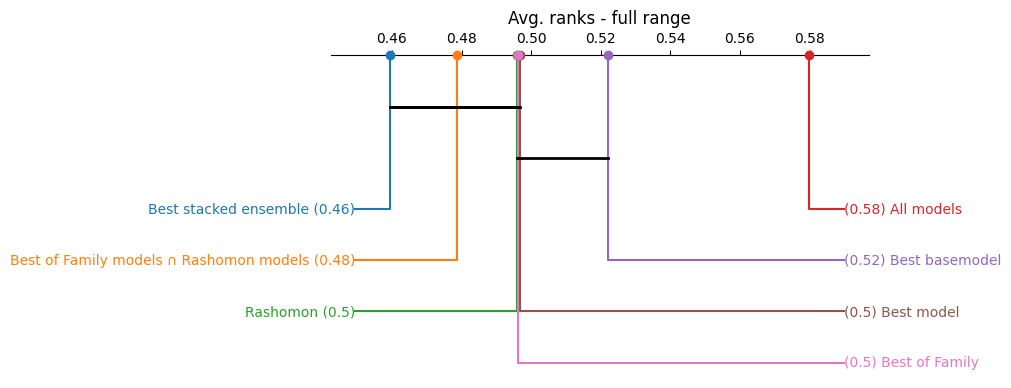

In [9]:
test_results = sp.posthoc_conover(
    subset,
    group_col='model',
    val_col='value',
)
plt.figure(figsize=(10,4))
sp.critical_difference_diagram(avg_rank, test_results)
plt.title("Avg. ranks - full range");
plt.tight_layout()
#plt.savefig("avg_ranks_full_range.png")

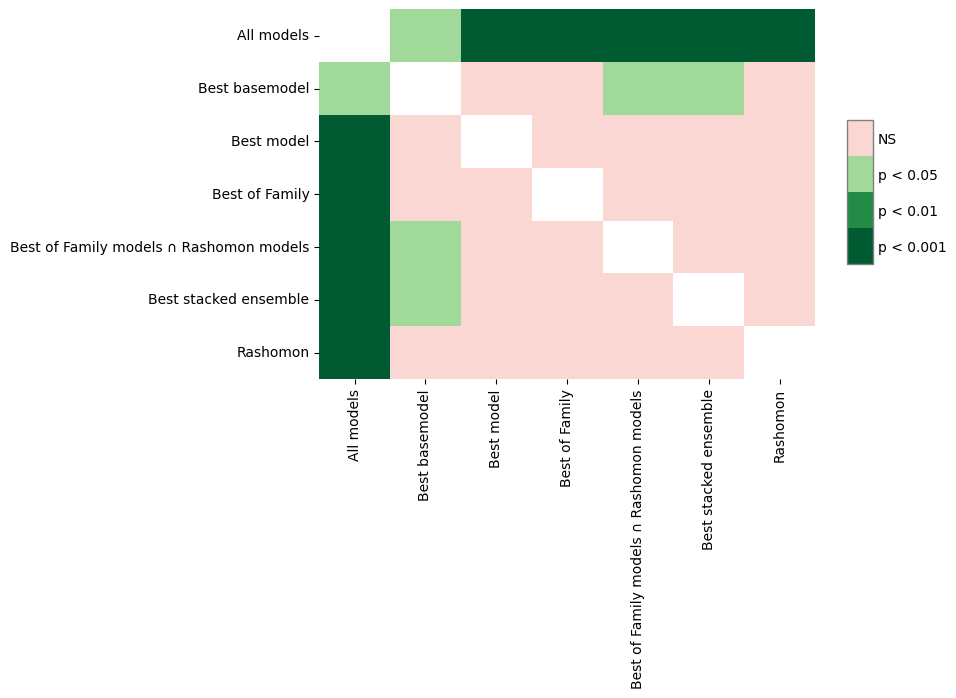

In [10]:
sp.sign_plot(test_results);